In [1]:
# automatically reload updated modules when they change during development
%load_ext autoreload
%autoreload 2

# External modules

import torch
import numpy as np
import random

# Internal modules

from data_analysis_fcns.DIL_Logger import DIL_Logger
from data_analysis_fcns.DIL_Metrics import plot_results
from data_analysis_fcns import count_parameters, plot_expert_loads

from experiment_fcns import load_config

from dataset_fcns import plot_partition_distributions
from models_fcns import create_model


# CUDA check

print("cuda" if torch.cuda.is_available() else "cpu")

cuda


Loading experiment configuration from configs/debug.json
 dataset         : cifar10 @ ./datasets
 partitions      : 5  type=dirichlet 
 model           : resnet18
 epochs_per_dom  : 3
{
  "seeds": {
    "global": 43
  },
  "dataset": "cifar10",
  "dataset_root": "./datasets",
  "mini_dataset": 1000,
  "num_partitions": 5,
  "partition": {
    "type": "dirichlet",
    "alpha": 0.3,
    "min_size": 10,
    "balanced": false
  },
  "train_frac": 0.8,
  "batch_size": 128,
  "shuffle": true,
  "pretrain": {
    "enabled": false,
    "num_samples": 0,
    "with_replacement": false
  },
  "replay": {
    "enabled": false,
    "capacity": 1000,
    "policy": "fifo"
  },
  "model": {
    "name": "resnet18",
    "num_classes": 10,
    "pretrained": false
  },
  "loss": {
    "name": "cross_entropy",
    "lr": 0.001
  },
  "optimizer": {
    "name": "adam"
  },
  "scheduler": {
    "name": "cosine",
    "T_max": 5
  },
  "epochs_per_domain": 3,
  "router_balancing": false,
  "router_balance_stren

/home/edgelab/imac/continous-MoE/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
/home/edgelab/imac/continous-MoE/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/edgelab/imac/continous-MoE/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


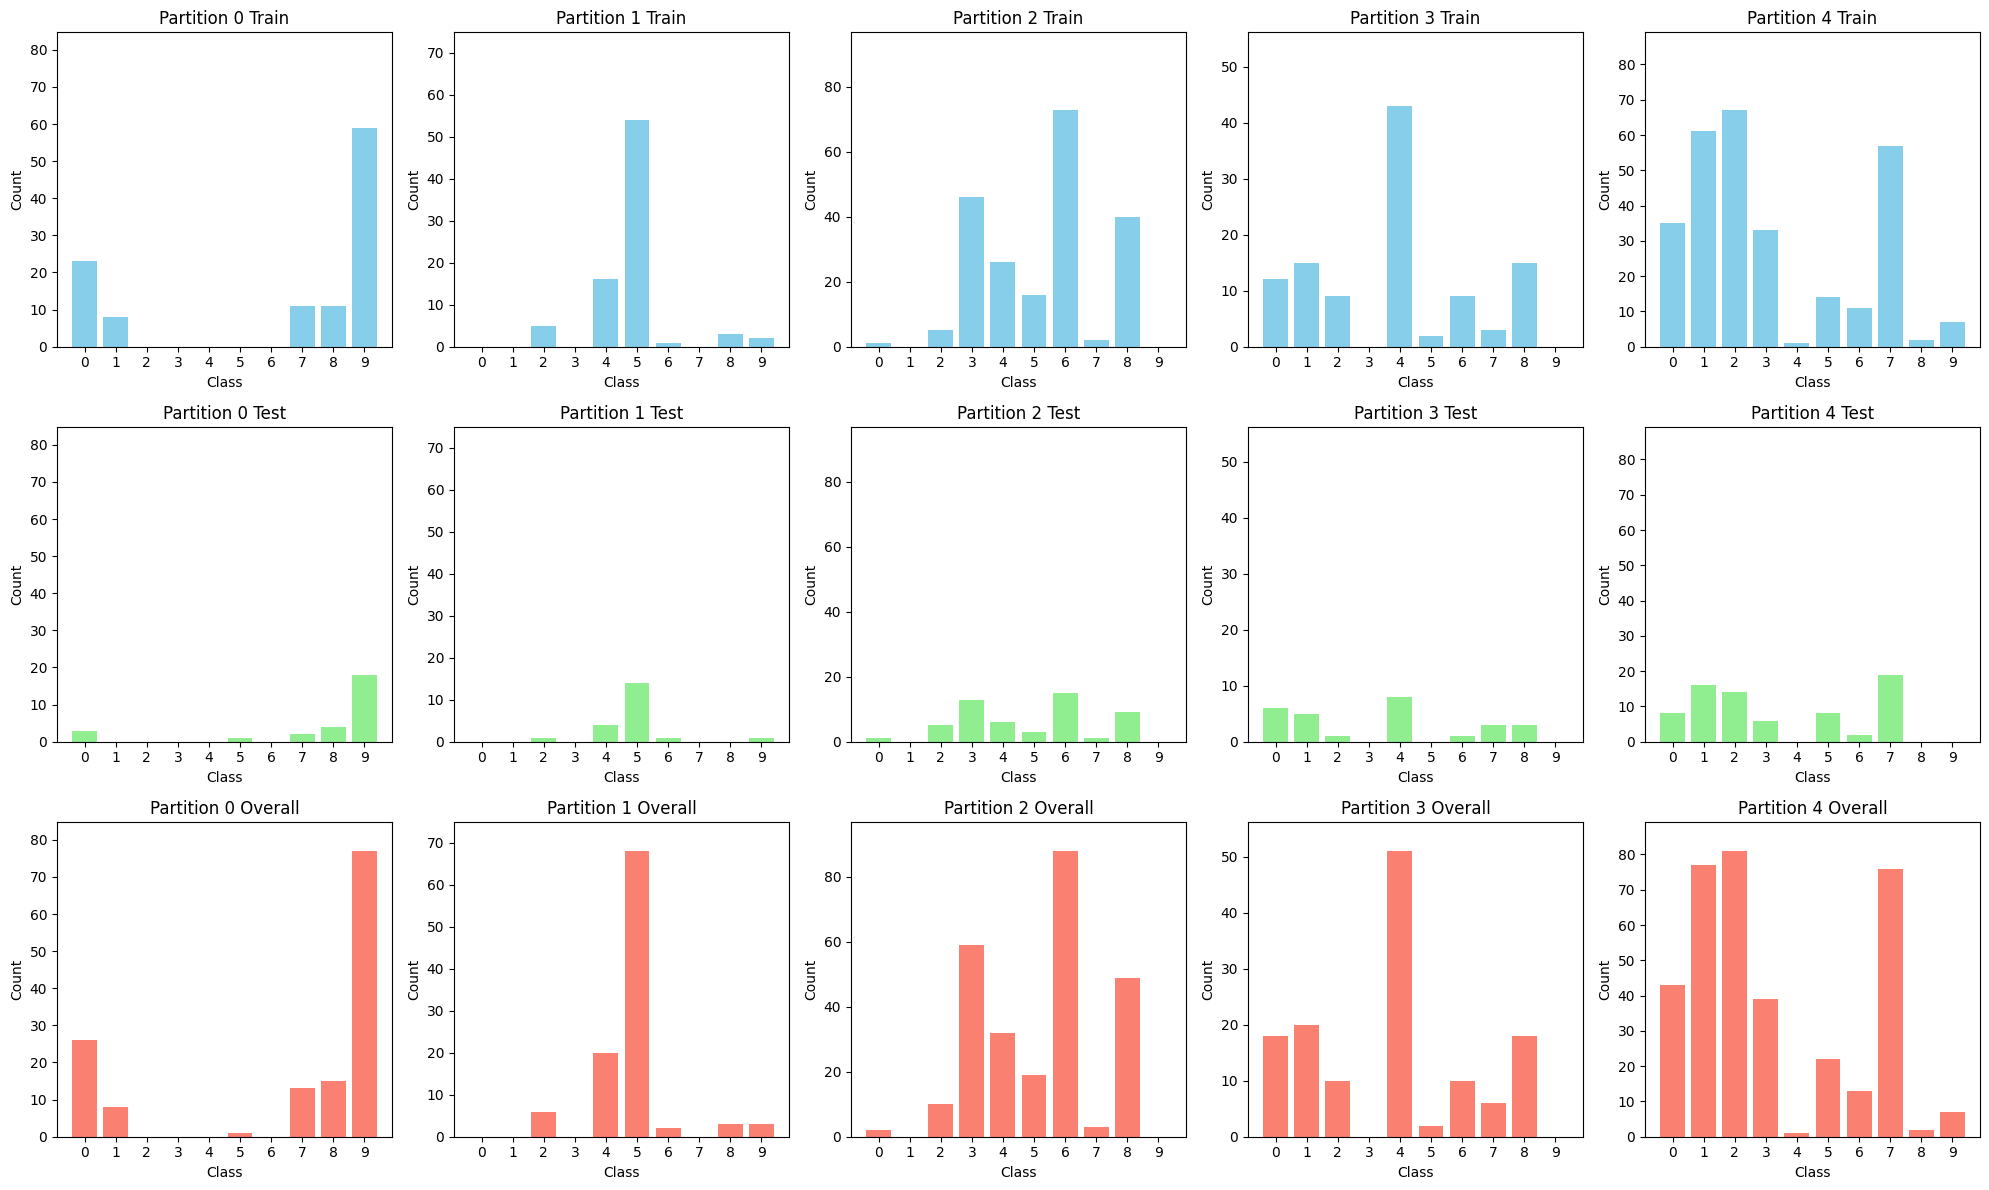

In [2]:
# ----------------------------------------
# Reproducibility and configuration
# ----------------------------------------

cfg_file = "configs/debug.json"  # change as needed
setup = load_config(cfg_file)
cfg = setup["cfg"]

device = setup["device"]

# objects returned by the loader
train_loaders = setup["train_loaders"]
test_loaders = setup["test_loaders"]
pretrain_loader = setup.get("pretrain_loader", None)
dataset = setup["dataset"]

num_classes = cfg.get("model", {}).get("num_classes", 10)
num_domains = len(train_loaders)
epochs_per_domain = cfg.get("epochs_per_domain", 5)

# helper used for baseline evaluation or quick checks
def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total

# optional baseline training (simple per-domain models to compute reference accuracies)
baseline_accs = None
if cfg.get("baseline", {}).get("train", False):
    print("Training baseline models for reference accuracies...")
    baseline_accs = []
    # apply model seed for reproducibility
    mseed = cfg.get("seeds", {}).get("model", cfg.get("seeds", {}).get("global", 0))
    torch.manual_seed(mseed)
    np.random.seed(mseed) 
    random.seed(mseed)
    for d in range(num_domains):
        bmodel = create_model(cfg).to(device)
        # recreate optimizer with same settings as the main run
        opt_cfg = cfg.get("optimizer", {"name": "adam"})
        lr = cfg.get("loss", {}).get("lr", opt_cfg.get("lr", 1e-3))
        if opt_cfg["name"].lower() == "adam":
            bopt = torch.optim.Adam(bmodel.parameters(), lr=lr)
        elif opt_cfg["name"].lower() == "sgd":
            bopt = torch.optim.SGD(bmodel.parameters(), lr=lr,
                                    momentum=opt_cfg.get("momentum", 0.0))
        else:
            raise ValueError(f"Unsupported optimizer {opt_cfg['name']}")
        for _ in range(epochs_per_domain):
            bmodel.train()
            for x, y in train_loaders[d]:
                x, y = x.to(device), y.to(device)
                bopt.zero_grad()
                loss = setup["criterion"](bmodel(x), y)
                loss.backward()
                bopt.step()
        acc = evaluate_accuracy(bmodel, test_loaders[d], device)
        baseline_accs.append(acc)
    print("Baseline accuracies per domain:", baseline_accs)

# plot partition distributions for sanity check
plot_partition_distributions(train_loaders, test_loaders, num_classes=num_classes)


In [3]:
# ----------------------------------------
# Model, optimizer, scheduler, loss
# ----------------------------------------

model = setup["model"].to(device)
optimizer = setup["optimizer"]
criterion = setup["criterion"]
scheduler = setup.get("scheduler", None)

# ----------------------------------------
# Continual Logger
# ----------------------------------------
baseline_val = baseline_accs if 'baseline_accs' in globals() and baseline_accs is not None else None
if baseline_val is None and cfg.get("baseline", {}).get("enabled", False):
    baseline_val = cfg.get("baseline", {}).get("accuracies", None)
    print("Using baseline accuracies from config for metric computation")
elif baseline_val is not None:
    print("Using computed baseline accuracies for metric computation")
logger = DIL_Logger(
    N=num_domains,
    C=num_classes,
    baseline=baseline_val,
    save_dir=cfg.get("save_dir", "results"),
    config_file=cfg_file
)



In [4]:
# ----------------------------------------
# Training helpers
# ----------------------------------------

# replay buffer
from dataset_fcns.replay import ReplayBuffer
replay_cfg = cfg.get("replay", {})
replay_buffer = None
if replay_cfg.get("enabled", False):
    replay_buffer = ReplayBuffer(
        capacity=replay_cfg.get("capacity", 1000),
        policy=replay_cfg.get("policy", "fifo"),
    )

# auxiliary loss (router balancing, etc.)
def compute_aux_loss(model, cfg):
    loss_aux = 0.0
    if cfg.get("router_balancing", False):
        strength = cfg.get("router_balance_strength", 0.1)
        for m in model.modules():
            if hasattr(m, '_last_gate_probs') and m._last_gate_probs is not None:
                p_mean = m._last_gate_probs.mean(dim=0)
                target = torch.full_like(p_mean, 1.0 / float(max(1, m.num_experts)))
                loss_aux = loss_aux + ((p_mean - target) ** 2).mean()
        loss_aux = strength * loss_aux
    return loss_aux

# parameter counts
total_params, active_params = count_parameters(model)
print(f"Model parameters: total={total_params:,}, active≈{active_params:,}")

# optionally print model structure
print(model)

Model parameters: total=11,181,642, active≈11,181,642
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

In [ ]:
# ----------------------------------------
# Training loop
# ----------------------------------------

# set training seed before loop
train_seed = cfg.get("seeds", {}).get("training", cfg.get("seeds", {}).get("global", 0))
torch.manual_seed(train_seed); np.random.seed(train_seed); random.seed(train_seed)

global_step = 0
for domain_id in range(num_domains):

    print(f"\n===== Training Domain {domain_id} =====")

    train_loader = train_loaders[domain_id]

    if scheduler is not None:
        # recreate scheduler per-domain if necessary
        scheduler = setup.get("scheduler")

    for epoch in range(epochs_per_domain):

        # -----------------------------
        # Train
        # -----------------------------
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)

            # replay samples
            if replay_buffer is not None:
                rx, ry = replay_buffer.sample(y.size(0))
                if rx.numel() > 0:
                    rx, ry = rx.to(device), ry.to(device)
                    rlogits = model(rx)
                    loss = loss + criterion(rlogits, ry)

            # auxiliary loss (router balancing etc.)
            aux = compute_aux_loss(model, cfg)
            if isinstance(aux, torch.Tensor):
                loss = loss + aux

            loss.backward()
            optimizer.step()

            global_step += 1

            # add to replay buffer
            if replay_buffer is not None:
                replay_buffer.add_batch(x.cpu(), y.cpu())

            # router freeze
            rf = cfg.get("router_freeze_after_batches")
            if rf is not None and global_step == rf and hasattr(model, 'freeze_routing'):
                model.freeze_routing(True)
                print("Router parameters frozen")

        if scheduler is not None:
            scheduler.step()

        # -----------------------------
        # Evaluate
        # -----------------------------
        domain_acc, overall_acc, preds, targets = \
            logger.evaluate(model, test_loaders, device)

        metrics = logger.compute_metrics(
            domain_id,
            epoch,
            domain_acc
        )

        metrics["overall_acc"] = float(overall_acc)

        logger.log(metrics)

        print(
            f"Epoch {epoch+1} | "
            f"Overall: {overall_acc:.4f} | "
            f"AvgInc: {metrics['avg_inc_acc']:.4f} | "
            f"Forgetting: {metrics['forgetting']:.4f}"
        )

    # -----------------------------
    # Finalize domain
    # -----------------------------
    logger.finalize_domain(domain_acc, preds, targets)


===== Training Domain 0 =====


Epoch 0 | Overall: 0.10 | AvgInc: 0.61 | Forgetting: 0.00
Epoch 1 | Overall: 0.09 | AvgInc: 0.11 | Forgetting: 0.00
Epoch 2 | Overall: 0.09 | AvgInc: 0.00 | Forgetting: 0.00

===== Training Domain 1 =====
Epoch 0 | Overall: 0.06 | AvgInc: 0.00 | Forgetting: 0.00
Epoch 1 | Overall: 0.05 | AvgInc: 0.04 | Forgetting: -0.07
Epoch 2 | Overall: 0.04 | AvgInc: 0.07 | Forgetting: -0.14

===== Training Domain 2 =====
Epoch 0 | Overall: 0.07 | AvgInc: 0.16 | Forgetting: -0.16
Epoch 1 | Overall: 0.09 | AvgInc: 0.04 | Forgetting: 0.02
Epoch 2 | Overall: 0.15 | AvgInc: 0.14 | Forgetting: 0.01

===== Training Domain 3 =====
Epoch 0 | Overall: 0.08 | AvgInc: 0.05 | Forgetting: 0.09
Epoch 1 | Overall: 0.09 | AvgInc: 0.06 | Forgetting: 0.08
Epoch 2 | Overall: 0.10 | AvgInc: 0.05 | Forgetting: 0.16

===== Training Domain 4 =====
Epoch 0 | Overall: 0.10 | AvgInc: 0.08 | Forgetting: 0.12
Epoch 1 | Overall: 0.10 | AvgInc: 0.10 | Forgetting: 0.05
Epoch 2 | Overall: 0.10 | AvgInc: 0.10 | Forgetting: 0.07


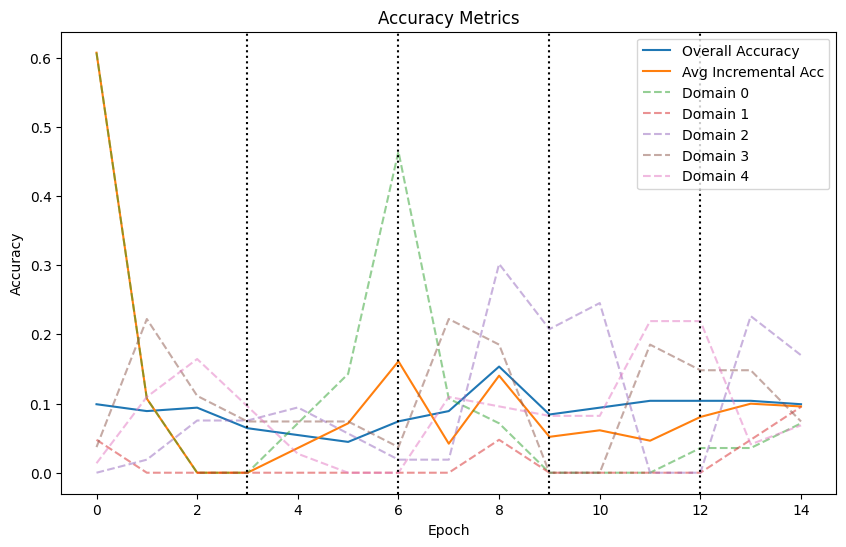

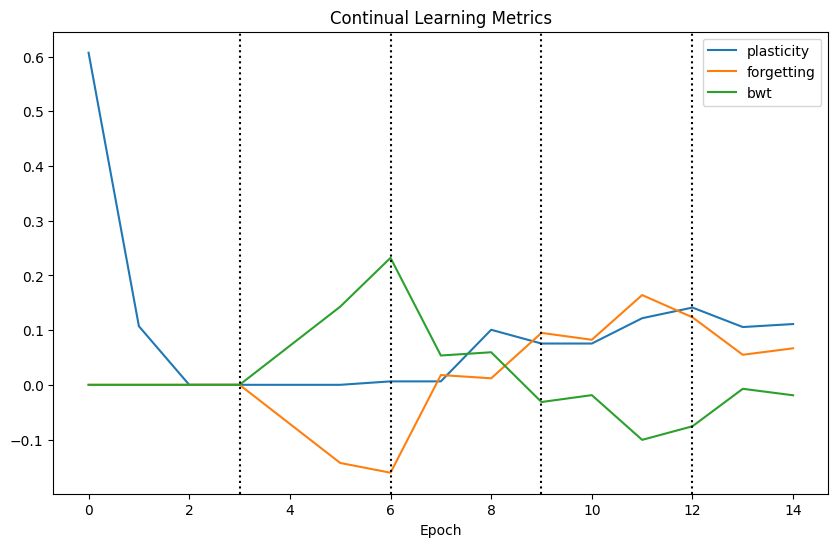

Model has no MoE layers; skipping expert load plot


In [6]:
# ----------------------------------------
# Save and Plot
# ----------------------------------------
logger.save()
plot_results(cfg.get("save_dir", "results"))

# expert load plot if MoE
plot_expert_loads(model)